# 温度駆動力を与える。固相液相の**多結晶**シミュレーションー＞GPU計算
# ー＞ https://doi.org/10.1016/j.mtla.2023.101702 の再現
# 固液界面のみ異方性

In [276]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
from numba import cuda, float32
from scipy.spatial.transform import Rotation

# =========================
# 0) Settings / Parameters
# =========================
nx, ny = 256, 256
number_of_grain = 10         # 0: liquid, 1..N-1: solid grains
dx, dy = 1e-4, 1e-4
dt = 0.00001
nsteps = 2000             # まず短め推奨（動作確認用）
pi = np.pi

delta = 10.0 * dx
T_melt = 1687.15
G = 1.0e+02
V_pulling = 5.0
latent = 4.15e+09

# ---- Energetic anisotropy (Appendix A / Table values you had) ----
a0 = 54.7 * pi / 180.0
delta_a = 0.36
mu_a = 0.6156
p_round = 0.05

# ---- Interface energies (scale you want) ----
# Solid-Liquid base energy (use (100) baseline)
gamma_100 = 0.44
# Grain boundary energy (isotropic)
gamma_GB = 0.60

# ---- Mobilities (choose reasonable constants) ----
# Grain boundary mobility (isotropic)
M_GB = 3.0e-5
# Solid-liquid mobility (isotropic here; you can later add b(theta))
M_SL = 3.0e-5

# Output
out_dir = "result/periodic/ani_quat"
os.makedirs(out_dir, exist_ok=True)

In [277]:
# =====================================
# 1) Grain orientations (quaternions)
# =====================================
np.random.seed(42)
N = number_of_grain
grain_quaternions = np.zeros((N, 4), dtype=np.float64)
grain_quaternions[0] = np.array([0, 0, 0, 1.0])  # liquid dummy (x,y,z,w)

for gid in range(1, N):
    q = np.random.normal(0, 1, 4)
    q = q / np.linalg.norm(q)
    grain_quaternions[gid] = q

# ---- Precompute rotated {111} normals (8) for each grain ----
n111_base = np.array([
    [ 1,  1,  1], [ 1,  1, -1], [ 1, -1,  1], [-1,  1,  1],
    [ 1, -1, -1], [-1,  1, -1], [-1, -1,  1], [-1, -1, -1],
], dtype=np.float32) / np.sqrt(3.0)

grain_n111 = np.zeros((N, 8, 3), dtype=np.float32)
for gid in range(N):
    Rm = Rotation.from_quat(grain_quaternions[gid]).as_matrix().astype(np.float32)
    grain_n111[gid] = (Rm @ n111_base.T).T  # (8,3)

In [278]:

# ==========================================================
# 2) Constant GB interactions (wij,aij,mij)  (i,j>0 constant)
#    and baseline SL constants (for reference only)
# ==========================================================
wij = np.zeros((N, N), dtype=np.float32)
aij = np.zeros((N, N), dtype=np.float32)
mij = np.zeros((N, N), dtype=np.float32)

In [279]:
# --- helper conversions ---
def eps_from_gamma(gamma):
    # epsilon = sqrt(8*delta*gamma/pi^2)
    return math.sqrt(8.0 * delta * gamma / (pi * pi))

def w_from_gamma(gamma):
    # w = 4*gamma/delta
    return 4.0 * gamma / delta

def mij_from_M(M):
    # mij(phi) = (pi^2/(8*delta)) * M   (same form you used)
    return (pi * pi / (8.0 * delta)) * M

# ---- GB constants (isotropic) ----
eps_GB = eps_from_gamma(gamma_GB)
w_GB = w_from_gamma(gamma_GB)
m_GB_phi = mij_from_M(M_GB)

for i in range(1, N):
    for j in range(1, N):
        if i == j:
            continue
        wij[i, j] = w_GB
        aij[i, j] = eps_GB
        mij[i, j] = m_GB_phi

# ---- SL baseline (100) ----
eps0_sl = eps_from_gamma(gamma_100)
w0_sl = w_from_gamma(gamma_100)
m_sl_phi = mij_from_M(M_SL)

for i in range(1, N):
    # store baseline (will be overwritten locally in kernel for anisotropy)
    wij[0, i] = wij[i, 0] = w0_sl
    aij[0, i] = aij[i, 0] = eps0_sl
    mij[0, i] = mij[i, 0] = m_sl_phi

In [280]:
NG = 10

@cuda.jit(device=True, inline=True)
def calc_a_from_cos(cosT, a0, delta_a, mu_a, p_round):
    # Appendix A (A2)-(A4)
    c2 = cosT*cosT
    C = math.sqrt(c2 + p_round*p_round)
    S = math.sqrt(max(1.0 - c2, 0.0) + p_round*p_round)
    return mu_a * (1.0 + delta_a * (C + math.tan(a0)*S))
@cuda.jit(device=True, inline=True)
def calc_a_theta_from_costh(cosT, a0, delta_a, mu_a, p_round):
    c2 = cosT * cosT
    C = math.sqrt(c2 + p_round * p_round)
    S = math.sqrt(max(1.0 - c2, 0.0) + p_round * p_round)
    return mu_a * (1.0 + delta_a * (C + math.tan(a0) * S))
@cuda.jit(device=True, inline=True)
def grad_phi(phi, gid, l, m, l_p, l_m, m_p, m_m, dx):
    gx = (phi[gid, l_p, m] - phi[gid, l_m, m]) * (0.5/dx)
    gy = (phi[gid, l, m_p] - phi[gid, l, m_m]) * (0.5/dx)  # dx=dy
    return gx, gy

@cuda.jit(device=True, inline=True)
def cos_theta_from_grad(gx, gy, n111, gid):
    g = math.sqrt(gx*gx + gy*gy) + 1e-20
    nxn = gx / g
    nyn = gy / g
    best = 0.0
    for t in range(8):
        n111x = n111[gid, t, 0]
        n111y = n111[gid, t, 1]
        c = abs(nxn*n111x + nyn*n111y)
        if c > best:
            best = c
    if best < 0.0: best = 0.0
    if best > 1.0: best = 1.0
    return best


In [281]:
from numba import cuda, float32
import math

# -----------------------------------------------------
# helper: x periodic, y clamp (same as kernel)
# -----------------------------------------------------
@cuda.jit(device=True, inline=True)
def idx_xp(l, nx):
    return l + 1 if l < nx - 1 else 0

@cuda.jit(device=True, inline=True)
def idx_xm(l, nx):
    return l - 1 if l > 0 else nx - 1

@cuda.jit(device=True, inline=True)
def idx_yp(m, ny):
    # Neumann: top is mirror (m stays)
    return m + 1 if m < ny - 1 else m

@cuda.jit(device=True, inline=True)
def idx_ym(m, ny):
    # Neumann: bottom is mirror (m stays at 0)
    return m - 1 if m > 0 else 0

@cuda.jit(device=True, inline=True)
def grad_phi_xy(phi, gid, l, m, nx, ny, dx):
    lp = idx_xp(l, nx)
    lm = idx_xm(l, nx)
    mp = idx_yp(m, ny)
    mm = idx_ym(m, ny)
    gx = (phi[gid, lp, m] - phi[gid, lm, m]) * (0.5 / dx)
    gy = (phi[gid, l, mp] - phi[gid, l, mm]) * (0.5 / dx)  # dx=dy の前提
    return gx, gy


# -----------------------------------------------------
# A1 anisotropic operator (Appendix A)
# x: periodic, y: clamp
# -----------------------------------------------------
@cuda.jit(device=True, inline=True)
def aniso_operator_A1(phi, gid, l, m, nx, ny,
                      dx, eps0_sl,
                      a0, delta_a, mu_a, p_round,
                      n111):

    # -------- center grad --------
    gx, gy = grad_phi_xy(phi, gid, l, m, nx, ny, dx)
    g2 = gx*gx + gy*gy
    g  = math.sqrt(g2) + 1e-20

    # nearest {111} and keep best normal (for torque derivative)
    nxn = gx/g
    nyn = gy/g
    best = 0.0
    best_nx = 1.0
    best_ny = 0.0
    for t in range(8):
        n111x = n111[gid, t, 0]
        n111y = n111[gid, t, 1]
        c = abs(nxn*n111x + nyn*n111y)
        if c > best:
            best = c
            best_nx = n111x
            best_ny = n111y

    cosT = best
    a = calc_a_theta_from_costh(cosT, a0, delta_a, mu_a, p_round)
    eps  = eps0_sl * a
    eps2 = eps * eps

    # -------- neighbor eps2 (center values at neighbor cells) --------
    lp = idx_xp(l, nx); lm = idx_xm(l, nx)
    mp = idx_yp(m, ny); mm = idx_ym(m, ny)

    gx_xp, gy_xp = grad_phi_xy(phi, gid, lp, m, nx, ny, dx)
    gx_xm, gy_xm = grad_phi_xy(phi, gid, lm, m, nx, ny, dx)
    gx_yp, gy_yp = grad_phi_xy(phi, gid, l, mp, nx, ny, dx)
    gx_ym, gy_ym = grad_phi_xy(phi, gid, l, mm, nx, ny, dx)

    cos_xp = cos_theta_from_grad(gx_xp, gy_xp, n111, gid)
    cos_xm = cos_theta_from_grad(gx_xm, gy_xm, n111, gid)
    cos_yp = cos_theta_from_grad(gx_yp, gy_yp, n111, gid)
    cos_ym = cos_theta_from_grad(gx_ym, gy_ym, n111, gid)

    a_xp = calc_a_theta_from_costh(cos_xp, a0, delta_a, mu_a, p_round)
    a_xm = calc_a_theta_from_costh(cos_xm, a0, delta_a, mu_a, p_round)
    a_yp = calc_a_theta_from_costh(cos_yp, a0, delta_a, mu_a, p_round)
    a_ym = calc_a_theta_from_costh(cos_ym, a0, delta_a, mu_a, p_round)

    eps2_xp = (eps0_sl*a_xp)*(eps0_sl*a_xp)
    eps2_xm = (eps0_sl*a_xm)*(eps0_sl*a_xm)
    eps2_yp = (eps0_sl*a_yp)*(eps0_sl*a_yp)
    eps2_ym = (eps0_sl*a_ym)*(eps0_sl*a_ym)

    # -------- term1: div(eps^2 grad phi) flux form --------
    Fx_p = 0.5*(eps2 + eps2_xp) * (phi[gid, lp, m] - phi[gid, l,  m]) / dx
    Fx_m = 0.5*(eps2 + eps2_xm) * (phi[gid, l,  m] - phi[gid, lm, m]) / dx
    Fy_p = 0.5*(eps2 + eps2_yp) * (phi[gid, l,  mp] - phi[gid, l,  m]) / dx
    Fy_m = 0.5*(eps2 + eps2_ym) * (phi[gid, l,  m]  - phi[gid, l,  mm]) / dx

    term1 = (Fx_p - Fx_m)/dx + (Fy_p - Fy_m)/dx

    # -------- term2: torque (あなたの式のまま。ただし安定化のため g2 に下限) --------
    u  = best_nx*gx + best_ny*gy
    au = abs(u) + 1e-20
    sgn = 1.0 if u >= 0.0 else -1.0
    du_dgx = sgn * best_nx
    du_dgy = sgn * best_ny

    # cos = abs(u)/g
    dcos_dgx = (du_dgx*g - au*(gx/g)) / (g*g)
    dcos_dgy = (du_dgy*g - au*(gy/g)) / (g*g)

    C = math.sqrt(cosT*cosT + p_round*p_round)
    S = math.sqrt(max(1.0 - cosT*cosT, 0.0) + p_round*p_round)
    da_dcos = mu_a * delta_a * ((cosT/C) + math.tan(a0)*(-cosT/S))

    deps_dgx = eps0_sl * (da_dcos * dcos_dgx)
    deps_dgy = eps0_sl * (da_dcos * dcos_dgy)

    inv_g2 = 1.0 / (g2 + 1e-12)   # ← ここは 1e-20 だと暴れやすい。まず 1e-12 推奨
    Qx = eps * deps_dgx * gx * inv_g2
    Qy = eps * deps_dgy * gy * inv_g2

    # divergence(Q) は “隣点のQ” を同様に作るのが厳密だけど、
    # まずは「中心Qの差分」で様子を見る（安定化優先）
    # Qx(x+) - Qx(x-) / 2dx, Qy(y+) - Qy(y-) / 2dx
    # ここでは簡易版（まず割れを止める）
    # ※厳密版に戻すのは、∑phi安定した後
    Qx_p = Qx; Qx_m = Qx
    Qy_p = Qy; Qy_m = Qy

    term2 = (Qx_p - Qx_m)/(2.0*dx) + (Qy_p - Qy_m)/(2.0*dx)

    return term1 + term2

In [282]:
@cuda.jit
def kernel_update_temp(temp, cooling_rate, nx, ny):
    l, m = cuda.grid(2)
    if l < nx and m < ny:
        temp[l, m] -= cooling_rate

In [283]:
@cuda.jit
def kernel_update_phasefield(phi, phi_new, temp,
                             wij, aij, mij,
                             n111,
                             nx, ny, number_of_grain, dx, dt,
                             T_melt, latent,
                             eps0_sl, w0_sl,
                             a0, delta_a, mu_a, p_round):

    l, m = cuda.grid(2)
    if l >= nx or m >= ny:
        return

    lp = idx_xp(l, nx); lm = idx_xm(l, nx)
    mp = idx_yp(m, ny); mm = idx_ym(m, ny)

    inv_dx2 = 1.0 / (dx * dx)

    lap_k = cuda.local.array(NG, dtype=float32)
    phi_c = cuda.local.array(NG, dtype=float32)

    for k in range(number_of_grain):
        pc = phi[k, l, m]
        phi_c[k] = pc
        lap_k[k] = (phi[k, lp, m] + phi[k, lm, m] +
                    phi[k, l,  mp] + phi[k, l,  mm] -
                    4.0 * pc) * inv_dx2

    # ---- 支配固相（界面法線用）----
    i_s = 1
    maxv = phi_c[1]
    for g in range(2, number_of_grain):
        v = phi_c[g]
        if v > maxv:
            maxv = v
            i_s = g

    # SL anisotropy for w only (your design)
    phix = (phi[i_s, lp, m] - phi[i_s, lm, m]) * (0.5 / dx)
    phiy = (phi[i_s, l, mp] - phi[i_s, l, mm]) * (0.5 / dx)
    gn = math.sqrt(phix * phix + phiy * phiy) + 1e-20
    nx_ = phix / gn
    ny_ = phiy / gn

    cmax = 0.0
    for t in range(8):
        n111x = n111[i_s, t, 0]
        n111y = n111[i_s, t, 1]
        c = abs(nx_ * n111x + ny_ * n111y)
        if c > cmax:
            cmax = c
    if cmax < 0.0: cmax = 0.0
    if cmax > 1.0: cmax = 1.0

    a_loc  = calc_a_theta_from_costh(cmax, a0, delta_a, mu_a, p_round)
    w_sl   = w0_sl * (a_loc * a_loc)

    # ---- driving force ----
    DeltaS = latent / T_melt
    Tcur = temp[l, m]

    # -------- update all phases --------
    for i in range(number_of_grain):
        dpi = 0.0
        for j in range(number_of_grain):
            if i == j:
                continue

            driving_force = 0.0
            if i != 0 and j == 0:
                driving_force = -DeltaS * (Tcur - T_melt)
            elif i == 0 and j != 0:
                driving_force =  DeltaS * (Tcur - T_melt)

            ppp = 0.0
            for k in range(number_of_grain):
                wik = wij[i, k]
                wjk = wij[j, k]

                if k == 0:
                    if i != 0: wik = w_sl
                    if j != 0: wjk = w_sl

                term1 = (wik - wjk) * phi_c[k]
                term2 = 0.0

                # gradient term
                if (j == 0 and i != 0):
                    if k == i:
                        lap_use = aniso_operator_A1(phi, i, l, m, nx, ny,
                                                    dx, eps0_sl, a0, delta_a, mu_a, p_round, n111)
                        term2 = 0.5 * lap_use
                elif (i == 0 and j != 0):
                    if k == j:
                        lap_use = aniso_operator_A1(phi, j, l, m, nx, ny,
                                                    dx, eps0_sl, a0, delta_a, mu_a, p_round, n111)
                        term2 = -0.5 * lap_use
                else:
                    eps2ik = aij[i, k] * aij[i, k]
                    eps2jk = aij[j, k] * aij[j, k]
                    term2  = 0.5 * (eps2ik - eps2jk) * lap_k[k]

                ppp += term1 + term2

            phii_phij = phi[i, l, m] * phi[j, l, m]
            term_force = (8.0 / 3.1415926535) * math.sqrt(max(phii_phij, 0.0)) * driving_force

            # num_phase を使うなら「中心だけ」で出す方が縞になりにくい
            # とりあえず固定係数で（安定化優先）
            dpi -= mij[i, j] * (ppp - term_force)

        phi_new[i, l, m] = phi[i, l, m] + dpi * dt

    # -------- projection: clip + normalize (超重要) --------
    s = 0.0
    for i in range(number_of_grain):
        v = phi_new[i, l, m]
        if v < 0.0: v = 0.0
        if v > 1.0: v = 1.0
        phi_new[i, l, m] = v
        s += v

    if s > 1e-20:
        invs = 1.0 / s
        for i in range(number_of_grain):
            phi_new[i, l, m] *= invs
    else:
        # もし全部0になったら液相に戻す
        phi_new[0, l, m] = 1.0
        for i in range(1, number_of_grain):
            phi_new[i, l, m] = 0.0


In [284]:
# =====================================================
# 4) Initialization
# =====================================================
phi_cpu = np.zeros((number_of_grain, nx, ny), dtype=np.float32)
seed_height = 32
factor = 2.0 / delta

n_solid = number_of_grain - 1
grain_width = nx // n_solid

for l in range(nx):
    grain_id = int(l // grain_width) + 1
    if grain_id > n_solid:
        grain_id = n_solid
    for m in range(ny):
        y = m * dy
        dist = y - (seed_height * dy)
        phi_solid = 0.5 * (1.0 - np.tanh(factor * dist))
        phi_cpu[grain_id, l, m] = phi_solid
        phi_cpu[0, l, m] = 1.0 - phi_solid

temp_cpu = np.zeros((nx, ny), dtype=np.float64)
for m in range(ny):
    temp_cpu[:, m] = T_melt - 1.0 + G * (m - seed_height) * dy

# quick plot step0
phase_map = np.argmax(phi_cpu, axis=0)
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)
plt.imshow(phase_map.T, cmap="tab20", origin="lower", interpolation="nearest")
plt.colorbar(ticks=range(number_of_grain), label="Phase ID")
plt.title("Initial Grain Map")

plt.subplot(1, 3, 2)
plt.imshow(temp_cpu.T, cmap="hot", origin="lower")
plt.colorbar(label="T [K]")
plt.title("Initial Temperature")

plt.subplot(1, 3, 3)
plt.imshow(phi_cpu[1].T, cmap="bwr", origin="lower", vmin=0, vmax=1)
plt.colorbar()
plt.title("phi(grain 1) step0")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "step_0.png"), dpi=150)
plt.close()

In [285]:
# dtypeを統一（推奨）
phi_cpu  = phi_cpu.astype(np.float32)
temp_cpu = temp_cpu.astype(np.float32)

d_phi     = cuda.to_device(phi_cpu)
d_phi_new = cuda.to_device(phi_cpu)
d_temp    = cuda.to_device(temp_cpu)
d_wij     = cuda.to_device(wij.astype(np.float32))
d_aij     = cuda.to_device(aij.astype(np.float32))
d_mij     = cuda.to_device(mij.astype(np.float32))
d_n111    = cuda.to_device(grain_n111.astype(np.float32))

threadsperblock = (16, 16)
blockspergrid = (math.ceil(nx / threadsperblock[0]),
                 math.ceil(ny / threadsperblock[1]))

cooling_rate = np.float32(G * V_pulling * dt)  # 温度固定なら0でOK
T_melt_f  = np.float32(T_melt)
latent_f  = np.float32(latent)
# もし kernel 側を ΔS入力に直すなら
# DeltaS_f = np.float32(latent / T_melt)

Step 100 | Tmin=1685.329 Tmax=1687.880
Step 200 | Tmin=1684.829 Tmax=1687.379
Step 300 | Tmin=1684.328 Tmax=1686.879
Step 400 | Tmin=1683.828 Tmax=1686.378
Step 500 | Tmin=1683.328 Tmax=1685.878
Step 600 | Tmin=1682.827 Tmax=1685.377
Step 700 | Tmin=1682.327 Tmax=1684.877
Step 800 | Tmin=1681.826 Tmax=1684.376
Step 900 | Tmin=1681.326 Tmax=1683.876
Step 1000 | Tmin=1680.825 Tmax=1683.375


KeyboardInterrupt: 

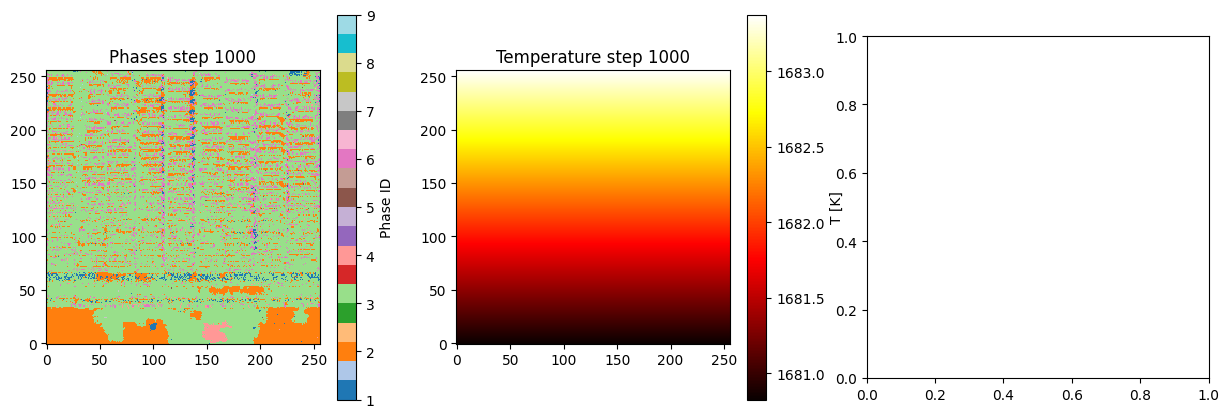

In [286]:
# =====================================================
# 6) Main loop
# =====================================================
save_every = 100

for nstep in range(1, nsteps + 1):
    kernel_update_temp[blockspergrid, threadsperblock](d_temp, cooling_rate, nx, ny)

    kernel_update_phasefield[blockspergrid, threadsperblock](
        d_phi, d_phi_new, d_temp,
        d_wij, d_aij, d_mij,
        d_n111,
        nx, ny, number_of_grain, np.float32(dx), np.float32(dt),
        T_melt_f, latent_f,
        np.float32(eps0_sl), np.float32(w0_sl),
        np.float32(a0), np.float32(delta_a), np.float32(mu_a), np.float32(p_round)
    )

    d_phi, d_phi_new = d_phi_new, d_phi

    if nstep % save_every == 0:
        current_phi  = d_phi.copy_to_host()
        phase_map = np.argmax(current_phi, axis=0)
        current_temp = d_temp.copy_to_host()
        print(f"Step {nstep} | Tmin={current_temp.min():.3f} Tmax={current_temp.max():.3f}")

        plt.figure(figsize=(15, 5))
        plt.subplot(1, 3, 1)
        plt.imshow(phase_map.T, cmap="tab20", origin="lower", interpolation="nearest")
        plt.colorbar(ticks=range(number_of_grain), label="Phase ID")
        plt.title(f"Phases step {nstep}")

        plt.subplot(1, 3, 2)
        plt.imshow(current_temp.T, cmap="hot", origin="lower")
        plt.colorbar(label="T [K]")
        plt.title(f"Temperature step {nstep}")

        plt.subplot(1, 3, 3)
        plt.imshow(current_phi[1].T, cmap="bwr", origin="lower", vmin=0, vmax=1)
        plt.colorbar()
        plt.title(f"phi(grain 1) step {nstep}")

        plt.tight_layout()
        plt.savefig(os.path.join(out_dir, f"step_{nstep}.png"), dpi=150)
        plt.close()
